# 3D Feature Space Analysis: SST vs Chlorophyll-a vs SSL

This notebook explores the 3D relationship between Sea Surface Temperature (SST), Chlorophyll-a concentration, and Sea Surface Level (SSL), colored by month to reveal seasonal patterns.

In [1]:
# Import required libraries
import pickle
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import cmocean
from scipy.ndimage import gaussian_filter

## Load the Pickle Dataset

In [2]:
# Load the pickle file
with open(r'E:\satdata\Custom\yucatan_sst_chlor_cdom_ssl_2019.pkl', 'rb') as f:
    data = pickle.load(f)

df = data['data']
metadata = data['metadata']

print(f"Dataset loaded successfully!")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Total records: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nData availability:")
print(f"  SST: {df['sst'].notna().sum()} days")
print(f"  Chlorophyll: {df['chlorophyll'].notna().sum()} days")
print(f"  SSL: {df['ssl'].notna().sum()} days")

Dataset loaded successfully!
Date range: 2019-01-01 00:00:00 to 2020-01-01 00:00:00
Total records: 366
Columns: ['sst', 'sst_n_points', 'chlorophyll', 'chlor_n_points', 'cdom', 'ssl', 'ssl_n_points']

Data availability:
  SST: 323 days
  Chlorophyll: 327 days
  SSL: 365 days


## Extract and Flatten Data for 3D Scatter Plot

In [3]:
# Extract all data points from the gridded dataset
sst_values = []
chlor_values = []
ssl_values = []
month_values = []
lon_values = []
lat_values = []

for date_idx, row in df.iterrows():
    # Extract month from the date index (1-12)
    month = date_idx.month
    
    # Get SST, chlorophyll, and SSL grids
    sst_grid = row['sst']
    chlor_grid = row['chlorophyll']
    ssl_grid = row['ssl']
    
    # Skip if any grid is None or NaN
    if sst_grid is None or chlor_grid is None or ssl_grid is None:
        continue
    if isinstance(sst_grid, float) and np.isnan(sst_grid):
        continue
    if isinstance(chlor_grid, float) and np.isnan(chlor_grid):
        continue
    if isinstance(ssl_grid, float) and np.isnan(ssl_grid):
        continue
    
    # Convert to numpy arrays
    sst_array = np.array(sst_grid)
    chlor_array = np.array(chlor_grid)
    ssl_array = np.array(ssl_grid)
    
    # Apply Gaussian blur to SSL to remove block artefacts before flattening
    # NaN-safe: fill NaNs temporarily, blur, then restore
    ssl_nan_mask = np.isnan(ssl_array)
    if not ssl_nan_mask.all():
        ssl_filled = ssl_array.copy()
        ssl_filled[ssl_nan_mask] = np.nanmean(ssl_array)
        ssl_blurred = gaussian_filter(ssl_filled, sigma=2.0)
        ssl_blurred[ssl_nan_mask] = np.nan
        ssl_array = ssl_blurred
    
    # Flatten the grids
    sst_flat = sst_array.flatten()
    chlor_flat = chlor_array.flatten()
    ssl_flat = ssl_array.flatten()
    
    # Get longitude and latitude grids from metadata
    lon_grid = metadata['lon_centers']
    lat_grid = metadata['lat_centers']
    
    # Create meshgrid for lon/lat if they are 1D arrays
    if lon_grid.ndim == 1 and lat_grid.ndim == 1:
        lon_2d, lat_2d = np.meshgrid(lon_grid, lat_grid)
    else:
        lon_2d = lon_grid
        lat_2d = lat_grid
    
    # Flatten lon/lat grids
    lon_flat = lon_2d.flatten()
    lat_flat = lat_2d.flatten()
    
    # Create mask for valid data (all three must be valid AND chlorophyll must be positive for log scale)
    valid_mask = ~np.isnan(sst_flat) & ~np.isnan(chlor_flat) & ~np.isnan(ssl_flat) & (chlor_flat > 0)
    
    # Append valid data points
    sst_values.extend(sst_flat[valid_mask])
    chlor_values.extend(chlor_flat[valid_mask])
    ssl_values.extend(ssl_flat[valid_mask])
    month_values.extend([month] * np.sum(valid_mask))
    lon_values.extend(lon_flat[valid_mask])
    lat_values.extend(lat_flat[valid_mask])

# Convert to numpy arrays
sst_values = np.array(sst_values)
chlor_values = np.array(chlor_values)
ssl_values = np.array(ssl_values)
month_values = np.array(month_values)
lon_values = np.array(lon_values)
lat_values = np.array(lat_values)

print(f"Total valid data points before subsampling: {len(sst_values):,}")

# Subsample to manageable number of points for 3D plotting
max_points = 5000
if len(sst_values) > max_points:
    # Generate random indices
    np.random.seed(42)  # For reproducibility
    random_indices = np.random.choice(len(sst_values), size=max_points, replace=False)
    
    # Subsample all arrays
    sst_values = sst_values[random_indices]
    chlor_values = chlor_values[random_indices]
    ssl_values = ssl_values[random_indices]
    month_values = month_values[random_indices]
    lon_values = lon_values[random_indices]
    lat_values = lat_values[random_indices]
    
    print(f"Subsampled to {max_points:,} points")

else:
    print(f"Using all {len(sst_values):,} points (less than {max_points:,})")

print(f"Months represented: {sorted(np.unique(month_values))}")
print(f"Latitude range: {np.min(lat_values):.2f} to {np.max(lat_values):.2f}°")
print(f"\nSST range: {np.min(sst_values):.2f} to {np.max(sst_values):.2f} °C")
print(f"Longitude range: {np.min(lon_values):.2f} to {np.max(lon_values):.2f}°")
print(f"Chlorophyll range: {np.min(chlor_values):.4f} to {np.max(chlor_values):.4f} mg/m³")
print(f"SSL range: {np.min(ssl_values):.4f} to {np.max(ssl_values):.4f} m")

Total valid data points before subsampling: 4,901,051
Subsampled to 5,000 points
Months represented: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
Latitude range: 19.59 to 22.86°

SST range: 22.57 to 31.21 °C
Longitude range: -92.19 to -85.63°
Chlorophyll range: 0.0277 to 54.0628 mg/m³
SSL range: 0.0930 to 1.0929 m


In [4]:
# Check metadata contents
print("Metadata keys:", metadata.keys())
for key, value in metadata.items():
    if hasattr(value, 'shape'):
        print(f"  {key}: shape = {value.shape}, type = {type(value)}")
    else:
        print(f"  {key}: type = {type(value)}, value = {value}")


Metadata keys: dict_keys(['lat_centers', 'lon_centers', 'lat_edges', 'lon_edges', 'bbox', 'grid_shape'])
  lat_centers: shape = (250,), type = <class 'numpy.ndarray'>
  lon_centers: shape = (250,), type = <class 'numpy.ndarray'>
  lat_edges: shape = (251,), type = <class 'numpy.ndarray'>
  lon_edges: shape = (251,), type = <class 'numpy.ndarray'>
  bbox: type = <class 'tuple'>, value = (-92.20216, -85.61256, 19.57871, 22.86906)
  grid_shape: type = <class 'tuple'>, value = (250, 250)


## Create 3D Scatter Plot: SST vs Chlorophyll-a vs SSL (Colored by Month)

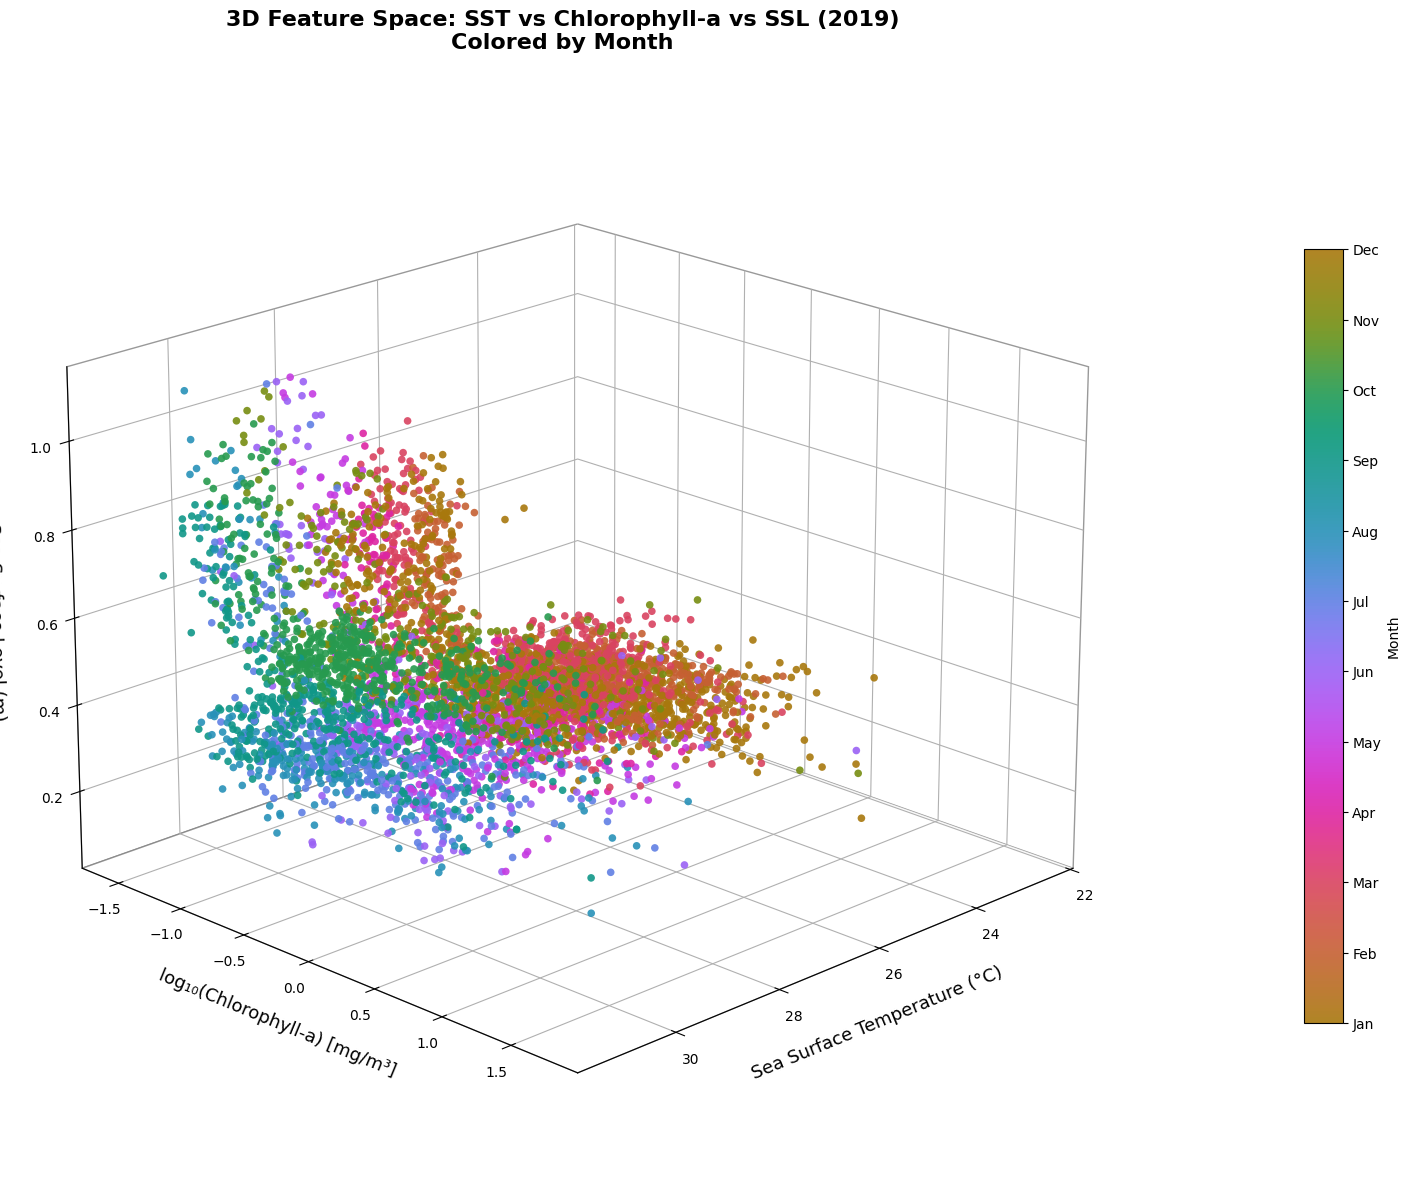

3D scatter plot created with 5,000 data points


In [5]:
# Create the 3D scatter plot
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111, projection='3d')

# Manually log-transform chlorophyll values for proper 3D visualization
chlor_log = np.log10(chlor_values)

# Create scatter plot with month as color
# Use cmocean.cm.phase for cyclic month coloring
scatter = ax.scatter(
    sst_values, 
    chlor_log,  # Use log-transformed values
    ssl_values,
    c=month_values,
    cmap=cmocean.cm.phase,
    s=30,  # Much larger point size for visibility
    alpha=0.9,  # Very opaque
    vmin=1,  # January
    vmax=12,  # December
    edgecolors='none',
    depthshade=False
)

# Set labels
ax.set_xlabel('Sea Surface Temperature (°C)', fontsize=13, labelpad=12)
ax.set_ylabel('log₁₀(Chlorophyll-a) [mg/m³]', fontsize=13, labelpad=12)
ax.set_zlabel('Sea Surface Level (m)', fontsize=13, labelpad=12)

# Set title
ax.set_title('3D Feature Space: SST vs Chlorophyll-a vs SSL (2019)\nColored by Month', 
             fontsize=16, fontweight='bold', pad=25)

# Add colorbar with month labels
cbar = plt.colorbar(scatter, ax=ax, label='Month', pad=0.12, shrink=0.7)
cbar.set_ticks(np.arange(1, 13))
cbar.ax.set_yticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Adjust viewing angle for better perspective
ax.view_init(elev=20, azim=45)

# Add grid
ax.grid(True, alpha=0.4, linestyle='--', linewidth=0.8)

# Improve plot appearance - make background white
ax.xaxis.pane.fill = True
ax.yaxis.pane.fill = True
ax.zaxis.pane.fill = True
ax.xaxis.pane.set_facecolor('white')
ax.yaxis.pane.set_facecolor('white')
ax.zaxis.pane.set_facecolor('white')

# Make pane edges more visible
ax.xaxis.pane.set_edgecolor('gray')
ax.yaxis.pane.set_edgecolor('gray')
ax.zaxis.pane.set_edgecolor('gray')
ax.xaxis.pane.set_alpha(0.8)
ax.yaxis.pane.set_alpha(0.8)
ax.zaxis.pane.set_alpha(0.8)

plt.tight_layout()
plt.show()


print(f"3D scatter plot created with {len(sst_values):,} data points")

In [6]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Prepare feature matrix (4 features)
# Use log-transformed chlorophyll for better distribution
chlor_log = np.log10(chlor_values)

features = np.column_stack([
    chlor_log,      # Log-transformed chlorophyll
    sst_values,     # Sea Surface Temperature
    ssl_values,     # Sea Surface Level
    month_values    # Month (continuous 1-12)
])

print(f"Feature matrix shape: {features.shape}")
print(f"Features: [log10(Chlor), SST, SSL, Month]")

# Standardize features (important for K-Means)
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

print(f"\nFeature scaling applied (mean=0, std=1)")

# Apply K-Means clustering with 4 clusters
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(features_scaled)

# Print cluster statistics
print(f"\nK-Means clustering with {n_clusters} clusters:")
for i in range(n_clusters):
    count = np.sum(cluster_labels == i)
    pct = 100 * count / len(cluster_labels)
    print(f"  Cluster {i}: {count:,} points ({pct:.1f}%)")

# Cluster centers in original feature space
cluster_centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
print(f"\nCluster centers (original scale):")
feature_names = ['log10(Chlor)', 'SST', 'SSL', 'Month']
for i in range(n_clusters):
    print(f"\n  Cluster {i}:")
    for j, name in enumerate(feature_names):
        print(f"    {name}: {cluster_centers_original[i, j]:.3f}")

# Compute PCA (2 components) on the scaled feature matrix for visualisation
pca = PCA(n_components=2)
features_pca = pca.fit_transform(features_scaled)
print(f"\nPCA computed — variance explained: PC1={100*pca.explained_variance_ratio_[0]:.1f}%, PC2={100*pca.explained_variance_ratio_[1]:.1f}% (total={100*pca.explained_variance_ratio_.sum():.1f}%)")


Feature matrix shape: (5000, 4)
Features: [log10(Chlor), SST, SSL, Month]

Feature scaling applied (mean=0, std=1)

K-Means clustering with 4 clusters:
  Cluster 0: 1,905 points (38.1%)
  Cluster 1: 737 points (14.7%)
  Cluster 2: 798 points (16.0%)
  Cluster 3: 1,560 points (31.2%)

Cluster centers (original scale):

  Cluster 0:
    log10(Chlor): -0.471
    SST: 25.415
    SSL: 0.316
    Month: 2.598

  Cluster 1:
    log10(Chlor): -1.132
    SST: 28.382
    SSL: 0.713
    Month: 6.140

  Cluster 2:
    log10(Chlor): 0.046
    SST: 27.778
    SSL: 0.359
    Month: 9.191

  Cluster 3:
    log10(Chlor): -0.847
    SST: 28.797
    SSL: 0.382
    Month: 8.720

PCA computed — variance explained: PC1=52.2%, PC2=26.4% (total=78.5%)


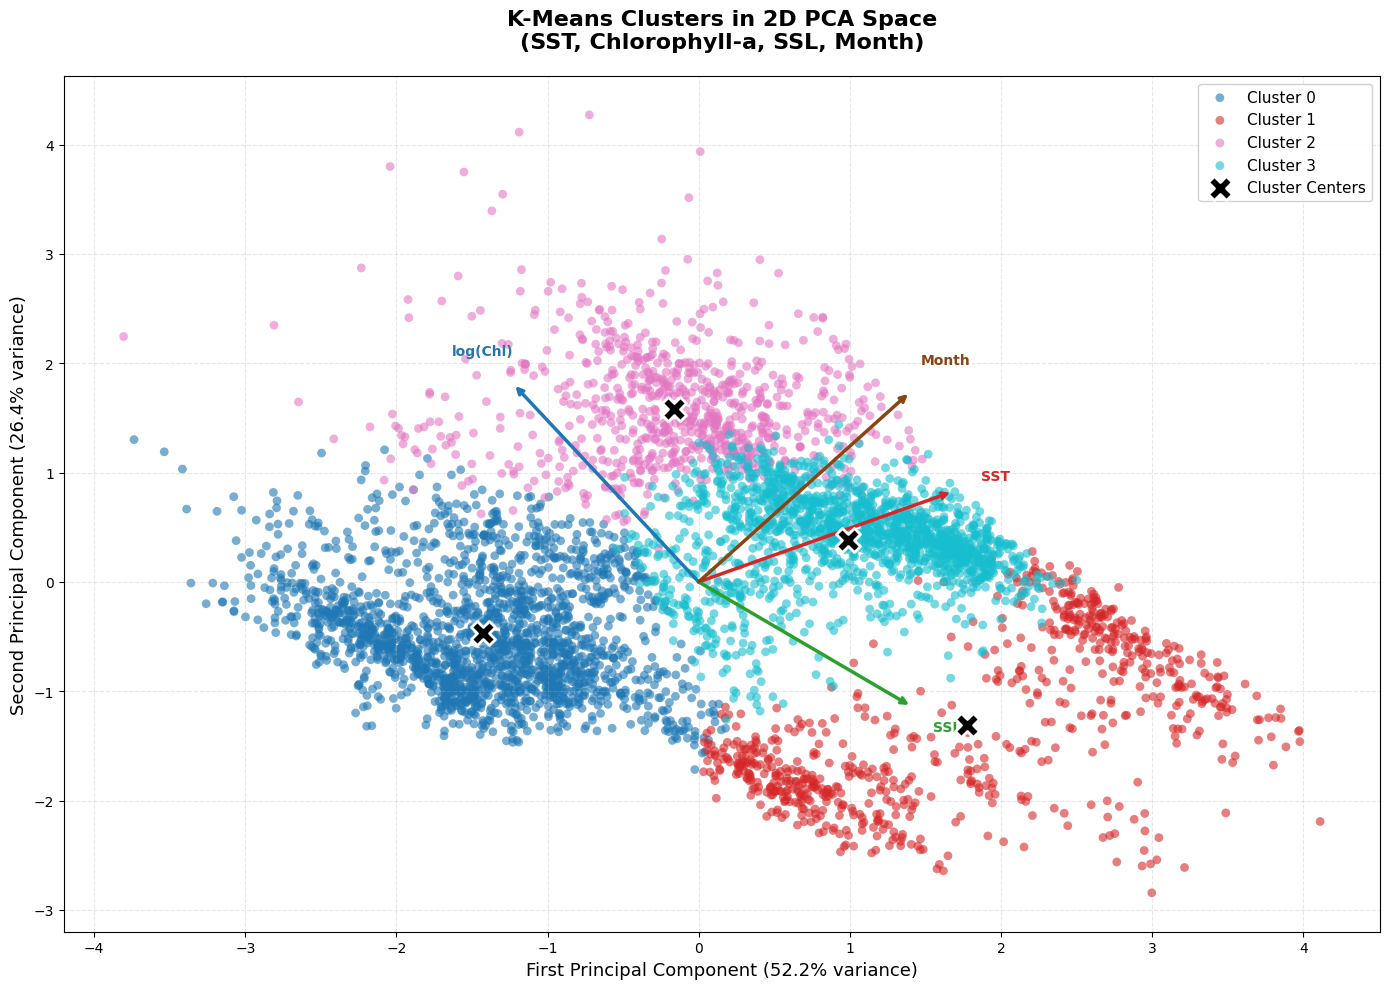


PCA visualization complete!
Total variance explained by 2 components: 78.5%


In [7]:
# Create 2D PCA visualization of clusters
fig, ax = plt.subplots(figsize=(14, 10))

# Define colors for clusters
cmap = plt.get_cmap('tab10', n_clusters)
colors = [cmap(i) for i in range(n_clusters)]
cluster_names = [f'Cluster {i}' for i in range(n_clusters)]

# Plot each cluster
for i in range(n_clusters):
    mask = cluster_labels == i
    ax.scatter(
        features_pca[mask, 0],
        features_pca[mask, 1],
        c=[colors[i]],
        label=cluster_names[i],
        s=40,
        alpha=0.6,
        edgecolors='none'
    )

# Plot cluster centers in PCA space
centers_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(
    centers_pca[:, 0],
    centers_pca[:, 1],
    c='black',
    marker='X',
    s=300,
    edgecolors='white',
    linewidths=2,
    label='Cluster Centers',
    zorder=5
)

# Labels and title
ax.set_xlabel(f'First Principal Component ({100*pca.explained_variance_ratio_[0]:.1f}% variance)', 
              fontsize=13)
ax.set_ylabel(f'Second Principal Component ({100*pca.explained_variance_ratio_[1]:.1f}% variance)', 
              fontsize=13)
ax.set_title('K-Means Clusters in 2D PCA Space\n(SST, Chlorophyll-a, SSL, Month)', 
             fontsize=16, fontweight='bold', pad=20)

# --- PCA loading rays (biplot arrows) ---
# Scale arrows to ~40% of the smaller axis range so they are clearly visible
x_range = features_pca[:, 0].max() - features_pca[:, 0].min()
y_range = features_pca[:, 1].max() - features_pca[:, 1].min()
arrow_scale = min(x_range, y_range) * 0.4

loading_feature_names = ['log(Chl)', 'SST', 'SSL', 'Month']
loading_colors = ['tab:blue', 'tab:red', 'tab:green', 'saddlebrown']

for j, (fname, fcolor) in enumerate(zip(loading_feature_names, loading_colors)):
    dx = pca.components_[0, j] * arrow_scale
    dy = pca.components_[1, j] * arrow_scale
    ax.annotate(
        '', xy=(dx, dy), xytext=(0, 0),
        arrowprops=dict(arrowstyle='->', color=fcolor, lw=2.5, shrinkA=0, shrinkB=0)
    )
    ax.text(dx * 1.18, dy * 1.18, fname, color=fcolor, fontsize=10,
            fontweight='bold', ha='center', va='center')

# Legend
ax.legend(loc='best', fontsize=11, framealpha=0.9)

# Grid
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

print(f"\nPCA visualization complete!")
print(f"Total variance explained by 2 components: {100*np.sum(pca.explained_variance_ratio_):.1f}%")


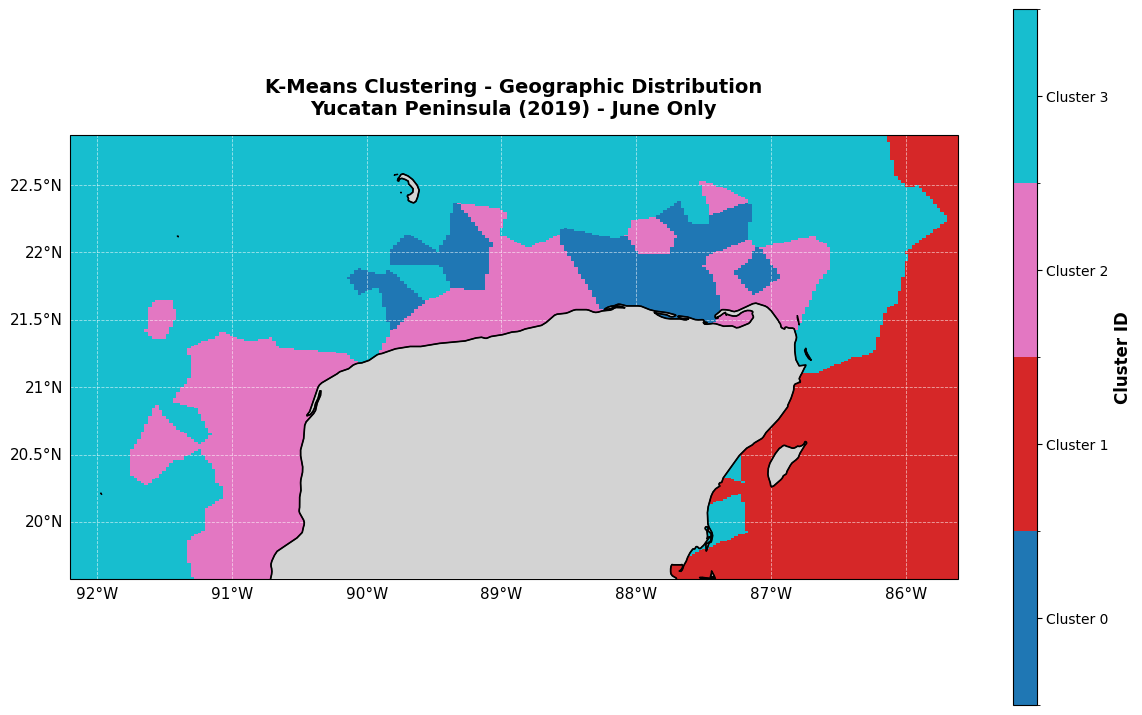


Geographic cluster map created for June!
Region: -92.20°W to -85.61°W, 19.58°N to 22.87°N
Grid shape: (250, 250)


In [8]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.interpolate import griddata

# Focus on June only
month_filter = 6
june_mask = month_values == month_filter

if not np.any(june_mask):
    raise ValueError(f"No data found for month {month_filter}")

lon_june = lon_values[june_mask]
lat_june = lat_values[june_mask]
cluster_june = cluster_labels[june_mask]

# Get the original grid shape from metadata
grid_shape = metadata['grid_shape']
lon_centers = metadata['lon_centers']
lat_centers = metadata['lat_centers']

# Create meshgrid for the original data grid
lon_grid_2d, lat_grid_2d = np.meshgrid(lon_centers, lat_centers)

# Interpolate cluster labels back to the original grid
# Use nearest neighbor interpolation to preserve discrete cluster values
points = np.column_stack([lon_june, lat_june])
cluster_grid = griddata(points, cluster_june, 
                        (lon_grid_2d, lat_grid_2d), 
                        method='nearest')

# Create custom colormap for the clusters
cmap_base = plt.get_cmap('tab10', n_clusters)
colors = [cmap_base(i) for i in range(n_clusters)]
cmap = ListedColormap(colors)
bounds = np.arange(-0.5, n_clusters + 0.5, 1)
norm = BoundaryNorm(bounds, cmap.N)

# Create geographic map with Cartopy
fig = plt.figure(figsize=(12, 9))
ax = plt.axes(projection=ccrs.PlateCarree())

# Set map extent to exact data bounds (no margin to avoid white borders)
# Using the exact Yucatan Peninsula data bounds
lat_min, lon_min = 19.57871, -92.20216  # Southwest corner
lat_max, lon_max = 22.86906, -85.61256  # Northeast corner
ax.set_extent([lon_min, lon_max, lat_min, lat_max], 
              crs=ccrs.PlateCarree())

# Plot the cluster grid as filled contours
mesh = ax.pcolormesh(lon_grid_2d, lat_grid_2d, cluster_grid, 
                     cmap=cmap, norm=norm,
                     transform=ccrs.PlateCarree(),
                     shading='auto', zorder=1)

# Add map features on top
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', 
               linewidth=0.8, zorder=3)
ax.add_feature(cfeature.COASTLINE, linewidth=1.2, zorder=4)

# Add gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.6, color='white', 
                  alpha=0.6, linestyle='--', zorder=2)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 11}
gl.ylabel_style = {'size': 11}

# Add colorbar with discrete labels
cluster_names = [f'Cluster {i}' for i in range(n_clusters)]
cbar = plt.colorbar(mesh, ax=ax, orientation='vertical', 
                    pad=0.05, shrink=0.8, aspect=30)
cbar.set_label('Cluster ID', fontsize=12, weight='bold')
cbar.set_ticks(np.arange(0, n_clusters, 1))
cbar.ax.set_yticklabels(cluster_names, fontsize=10)

# Title
plt.title('K-Means Clustering - Geographic Distribution\nYucatan Peninsula (2019) - June Only', 
          fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

print(f"\nGeographic cluster map created for June!")
print(f"Region: {lon_min:.2f}°W to {lon_max:.2f}°W, {lat_min:.2f}°N to {lat_max:.2f}°N")
print(f"Grid shape: {grid_shape}")

June dates found: 21


C:\Users\Makai\AppData\Local\Temp\ipykernel_13984\1849147045.py:43: RuntimeWarning: Mean of empty slice
  mean_sst   = np.nanmean(june_sst_grids, axis=0)
C:\Users\Makai\AppData\Local\Temp\ipykernel_13984\1849147045.py:44: RuntimeWarning: Mean of empty slice
  mean_chlor = np.nanmean(june_chlor_grids, axis=0)


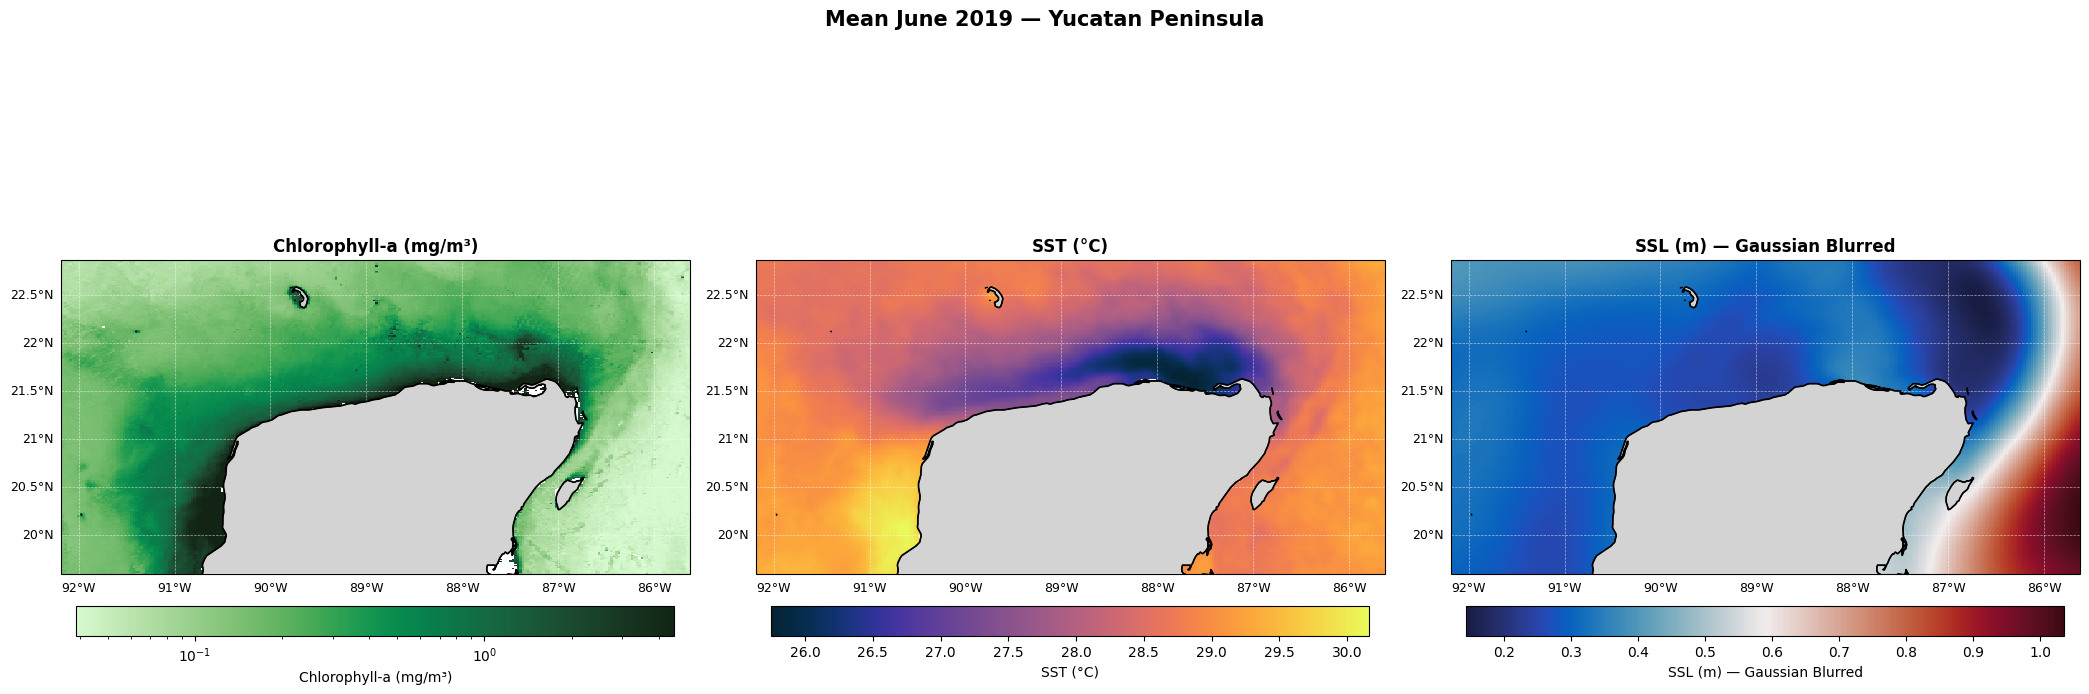

Chlorophyll range: 0.0277 – 84.9278 mg/m³
SST range:         25.75 – 30.16 °C
SSL range:         0.14358 – 1.03601 m


In [9]:

# Plot mean June grids: Chlorophyll-a, SST, and Gaussian-blurred SSL
from matplotlib.colors import LogNorm

lon_centers = metadata['lon_centers']
lat_centers = metadata['lat_centers']
lon_grid_2d, lat_grid_2d = np.meshgrid(lon_centers, lat_centers)

# Collect all June grids from the full dataset
june_sst_grids = []
june_chlor_grids = []
june_ssl_grids = []

for date_idx, row in df.iterrows():
    if date_idx.month != 6:
        continue
    sst_g   = row['sst']
    chlor_g = row['chlorophyll']
    ssl_g   = row['ssl']

    if any(v is None for v in [sst_g, chlor_g, ssl_g]):
        continue
    if any(isinstance(v, float) and np.isnan(v) for v in [sst_g, chlor_g, ssl_g]):
        continue

    june_sst_grids.append(np.array(sst_g))
    june_chlor_grids.append(np.array(chlor_g))

    # Apply Gaussian blur to SSL (NaN-safe)
    ssl_arr = np.array(ssl_g)
    ssl_nan_mask = np.isnan(ssl_arr)
    if not ssl_nan_mask.all():
        ssl_filled = ssl_arr.copy()
        ssl_filled[ssl_nan_mask] = np.nanmean(ssl_arr)
        ssl_b = gaussian_filter(ssl_filled, sigma=2.0)
        ssl_b[ssl_nan_mask] = np.nan
        june_ssl_grids.append(ssl_b)
    else:
        june_ssl_grids.append(ssl_arr)

print(f"June dates found: {len(june_sst_grids)}")

# Compute mean across all June dates
mean_sst   = np.nanmean(june_sst_grids, axis=0)
mean_chlor = np.nanmean(june_chlor_grids, axis=0)
mean_ssl   = np.nanmean(june_ssl_grids, axis=0)

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(21, 7),
                         subplot_kw={'projection': ccrs.PlateCarree()})

extent = [lon_centers.min(), lon_centers.max(), lat_centers.min(), lat_centers.max()]

panels = [
    (axes[0], mean_chlor, cmocean.cm.algae,   'Chlorophyll-a (mg/m³)', LogNorm(vmin=np.nanpercentile(mean_chlor[mean_chlor > 0], 2),
                                                                                  vmax=np.nanpercentile(mean_chlor[mean_chlor > 0], 98))),
    (axes[1], mean_sst,   cmocean.cm.thermal, 'SST (°C)',              None),
    (axes[2], mean_ssl,   cmocean.cm.balance, 'SSL (m) — Gaussian Blurred',
                                                                         None),
]

for ax, grid_data, cmap, label, norm in panels:
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    mesh = ax.pcolormesh(lon_grid_2d, lat_grid_2d, grid_data,
                         cmap=cmap, norm=norm,
                         transform=ccrs.PlateCarree(),
                         shading='auto', zorder=1)

    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black',
                   linewidth=0.8, zorder=3)
    ax.add_feature(cfeature.COASTLINE, linewidth=1.2, zorder=4)

    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='white',
                      alpha=0.6, linestyle='--', zorder=2)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 9}
    gl.ylabel_style = {'size': 9}

    plt.colorbar(mesh, ax=ax, orientation='horizontal', pad=0.05, shrink=0.95, label=label)
    ax.set_title(label, fontsize=12, fontweight='bold')

fig.suptitle('Mean June 2019 — Yucatan Peninsula', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Chlorophyll range: {np.nanmin(mean_chlor):.4f} – {np.nanmax(mean_chlor):.4f} mg/m³")
print(f"SST range:         {np.nanmin(mean_sst):.2f} – {np.nanmax(mean_sst):.2f} °C")
print(f"SSL range:         {np.nanmin(mean_ssl):.5f} – {np.nanmax(mean_ssl):.5f} m")


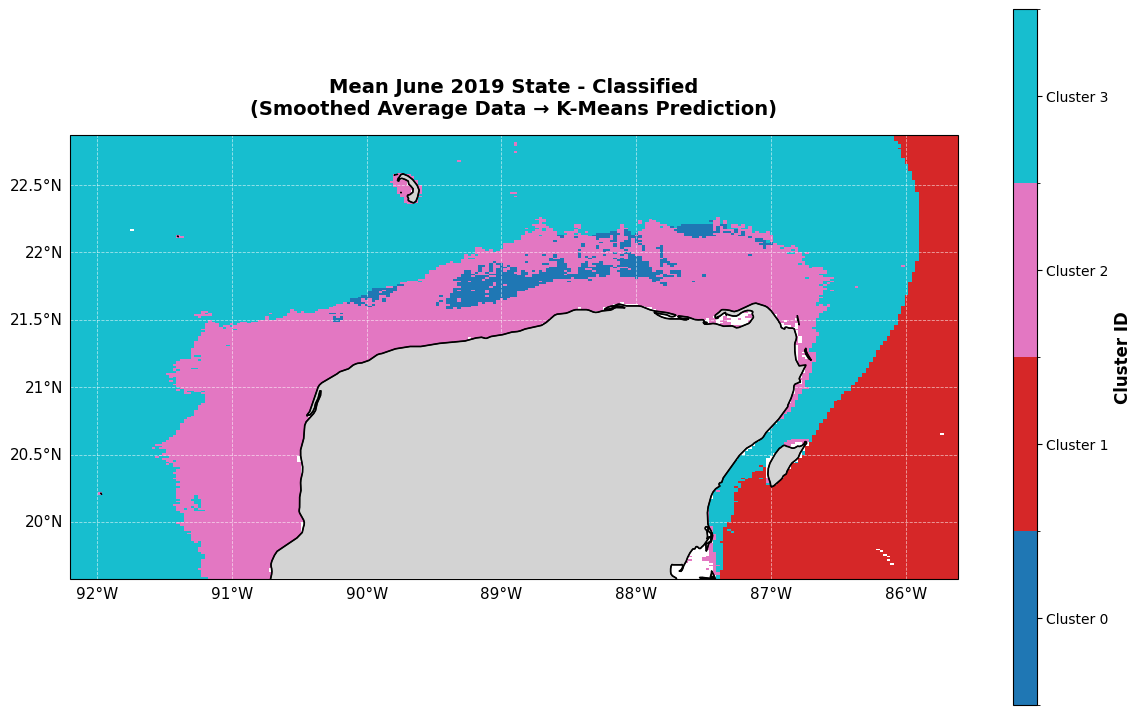

Mean June Map generated!
Valid pixels classifed: 44,735


In [10]:
# Flatten the mean grids to creating a feature matrix for "Mean June"
# This avoids the jagged "Nearest Neighbor" interpolation by clustering the smooth averages directly

# 1. Flatten the 2D mean grids
mean_chlor_flat = mean_chlor.flatten()
mean_sst_flat   = mean_sst.flatten()
mean_ssl_flat   = mean_ssl.flatten()

# 2. Create the mask for valid data (must be non-NaN in all variables)
# Note: chlor must be > 0 for log transform
valid_mask_mean = (
    ~np.isnan(mean_chlor_flat) & 
    ~np.isnan(mean_sst_flat) & 
    ~np.isnan(mean_ssl_flat) & 
    (mean_chlor_flat > 0)
)

# 3. Filter valid pixels
chlor_valid = mean_chlor_flat[valid_mask_mean]
sst_valid   = mean_sst_flat[valid_mask_mean]
ssl_valid   = mean_ssl_flat[valid_mask_mean]

# 4. Prepare features matching the training format: 
# [log10(Chlor), SST, SSL, Month]
# Set Month = 6.0 for everyone
mean_features = np.column_stack([
    np.log10(chlor_valid),           # log10(Chlor)
    sst_valid,                       # SST
    ssl_valid,                       # SSL
    np.full_like(sst_valid, 6.0)     # Month (June)
])

# 5. Scale features using the *existing* scaler from earlier
mean_features_scaled = scaler.transform(mean_features)

# 6. Predict clusters using the *existing* trained K-Means model
mean_clusters = kmeans.predict(mean_features_scaled)

# 7. Reconstruct the 2D cluster grid
# Initialize with NaNs (or a marker for no-data)
mean_cluster_grid = np.full(mean_chlor.shape, np.nan)
# Fill in the predicted labels at the valid positions
mean_cluster_grid.flat[valid_mask_mean] = mean_clusters


# --- PLOT THE SMOOTH CLUSTER MAP ---
fig = plt.figure(figsize=(12, 9))
ax = plt.axes(projection=ccrs.PlateCarree())

lat_min, lon_min = 19.57871, -92.20216
lat_max, lon_max = 22.86906, -85.61256
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Create custom colormap for the clusters (same as before)
cmap_base = plt.get_cmap('tab10', n_clusters)
colors = [cmap_base(i) for i in range(n_clusters)]
cmap = ListedColormap(colors)
bounds = np.arange(-0.5, n_clusters + 0.5, 1)
norm = BoundaryNorm(bounds, cmap.N)

# Plot using pcolormesh on the original coordinate grid
mesh = ax.pcolormesh(lon_grid_2d, lat_grid_2d, mean_cluster_grid, 
                     cmap=cmap, norm=norm,
                     transform=ccrs.PlateCarree(),
                     shading='auto', zorder=1)

ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.8, zorder=3)
ax.add_feature(cfeature.COASTLINE, linewidth=1.2, zorder=4)

gl = ax.gridlines(draw_labels=True, linewidth=0.6, color='white', alpha=0.6, linestyle='--', zorder=2)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 11}
gl.ylabel_style = {'size': 11}

cluster_names = [f'Cluster {i}' for i in range(n_clusters)]
cbar = plt.colorbar(mesh, ax=ax, orientation='vertical', pad=0.05, shrink=0.8, aspect=30)
cbar.set_label('Cluster ID', fontsize=12, weight='bold')
cbar.set_ticks(np.arange(0, n_clusters, 1))
cbar.ax.set_yticklabels(cluster_names, fontsize=10)

plt.title('Mean June 2019 State - Classified\n(Smoothed Average Data → K-Means Prediction)', 
          fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

print(f"Mean June Map generated!")
print(f"Valid pixels classifed: {np.sum(valid_mask_mean):,}")

attack from the supercomputer & save time | if it doesent work, stick to local

- remove lat and lon from feature space
- pickle full 5 yr dataset
- run kmeans again

- boxplot of pixels within upwelling of specral slopes
    - do both 275* and 300* look at absorption @ CDOM_412
    - confidence intervals

image of strong upwelling vs. weak upwelling

v2. 